In [1]:
# Part 4: Data Visualization & Machine Learning
# Theme: Student Performance Analysis & Prediction

In [2]:
# importing all required libraries for this assignment
# importing required libraries:
# numpy → numerical operations
# pandas → handling datasets (tables)
# matplotlib → basic plotting
# seaborn → better looking statistical graphs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# this makes seaborn plots look cleaner
sns.set_style("whitegrid")

In [3]:
# creating the students.csv file directly from the assignment data
# this is helpful in case the file is not already present in the project folder

csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open("students.csv", "w") as file:
    file.write(csv_data)

print("students.csv file created successfully.")

students.csv file created successfully.


In [4]:
# loading the dataset using pandas

df = pd.read_csv("students.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# showing the first 5 rows

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [6]:
# checking shape and data types

print("Shape of dataset (rows, columns):")
print(df.shape)

print("\nData types of each column:")
print(df.dtypes)

Shape of dataset (rows, columns):
(15, 9)

Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [7]:
# summary statistics for numeric columns

print("Summary statistics for numeric columns:")
df.describe()

Summary statistics for numeric columns:


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [8]:
# counting how many students passed and failed

print("Count of students who passed and failed:")
print(df["passed"].value_counts())

Count of students who passed and failed:
passed
1    9
0    6
Name: count, dtype: int64


In [9]:
# average subject scores for students who passed and failed

subjects = ["math", "science", "english", "history", "pe"]

passed_avg = df[df["passed"] == 1][subjects].mean()
failed_avg = df[df["passed"] == 0][subjects].mean()

print("Average subject scores for students who PASSED:")
print(passed_avg)

print("\nAverage subject scores for students who FAILED:")
print(failed_avg)

Average subject scores for students who PASSED:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average subject scores for students who FAILED:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [10]:
# finding the student with the highest average across 5 subjects

df["overall_avg"] = df[subjects].mean(axis=1)

top_student_row = df.loc[df["overall_avg"].idxmax()]

print("Student with the highest overall average:")
print("Name:", top_student_row["name"])
print("Average Score:", round(top_student_row["overall_avg"], 2))

Student with the highest overall average:
Name: Diana
Average Score: 94.0


In [11]:
# creating avg_score column for later visualizations

df["avg_score"] = df[subjects].mean(axis=1)

print("avg_score column added.")

avg_score column added.


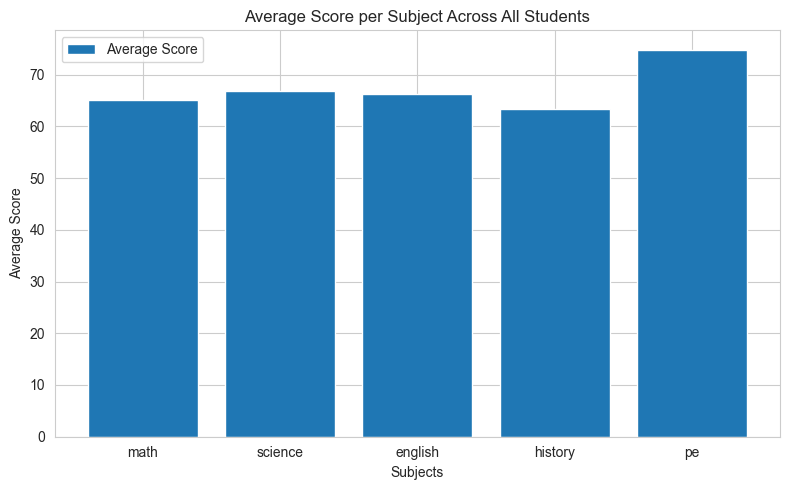

In [12]:
# Plot 1: bar chart for average score in each subject
# bar chart
# showing average score of each subject across all students
avg_subject_scores = df[subjects].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_subject_scores.index, avg_subject_scores.values, label="Average Score")
plt.title("Average Score per Subject Across All Students") # adding title for clarity
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()

plt.savefig("plot1_bar.png") # saving the plot as an image file
plt.show() # displaying the plot

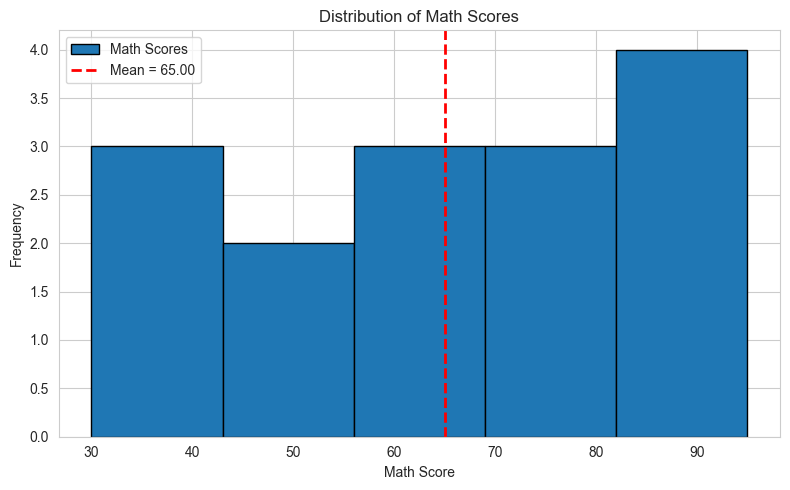

In [13]:
# Plot 2: histogram of math scores with mean line
# histogram
# showing distribution of math marks
math_mean = df["math"].mean()

plt.figure(figsize=(8, 5))
plt.hist(df["math"], bins=5, edgecolor="black", label="Math Scores")
plt.axvline(math_mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {math_mean:.2f}") # drawing a vertical line showing average math score

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.savefig("plot2_histogram.png")
plt.show()

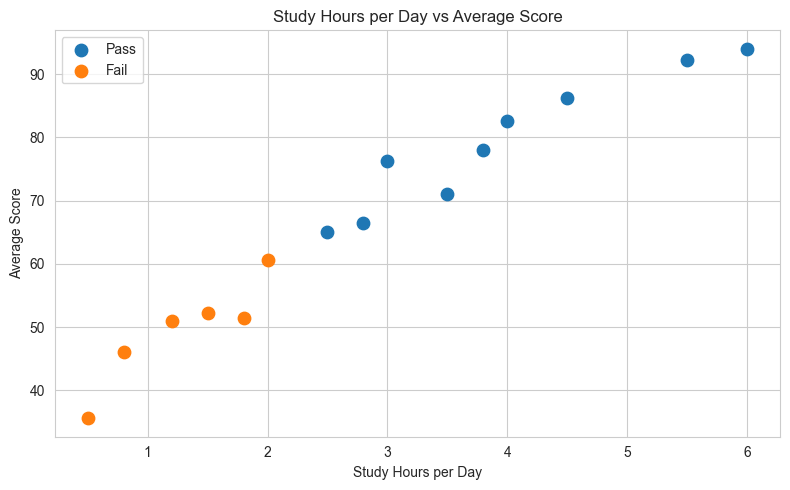

In [14]:
# Plot 3: scatter plot of study hours vs average score
# using separate scatter plots for pass and fail students
# scatter
# plotting study hours vs average score for students who passed and those who failed
pass_students = df[df["passed"] == 1]
fail_students = df[df["passed"] == 0]

plt.figure(figsize=(8, 5))

plt.scatter(pass_students["study_hours_per_day"], pass_students["avg_score"], label="Pass", s=80)
plt.scatter(fail_students["study_hours_per_day"], fail_students["avg_score"], label="Fail", s=80)

plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend() # showing legend to differentiate pass/fail
plt.tight_layout()

plt.savefig("plot3_scatter.png") # saving the plot
plt.show() # displaying final scatter plot

C:\Users\Kahani Tharayil\AppData\Local\Temp\ipykernel_2980\3070709141.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


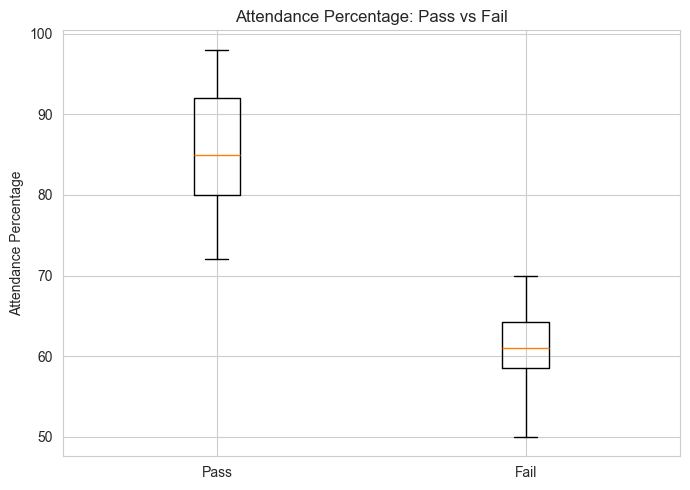

In [15]:
# Plot 4: box plot for attendance percentage of pass vs fail students

pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

plt.figure(figsize=(7, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])

plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance Percentage")
plt.tight_layout()

plt.savefig("plot4_box.png")
plt.show()

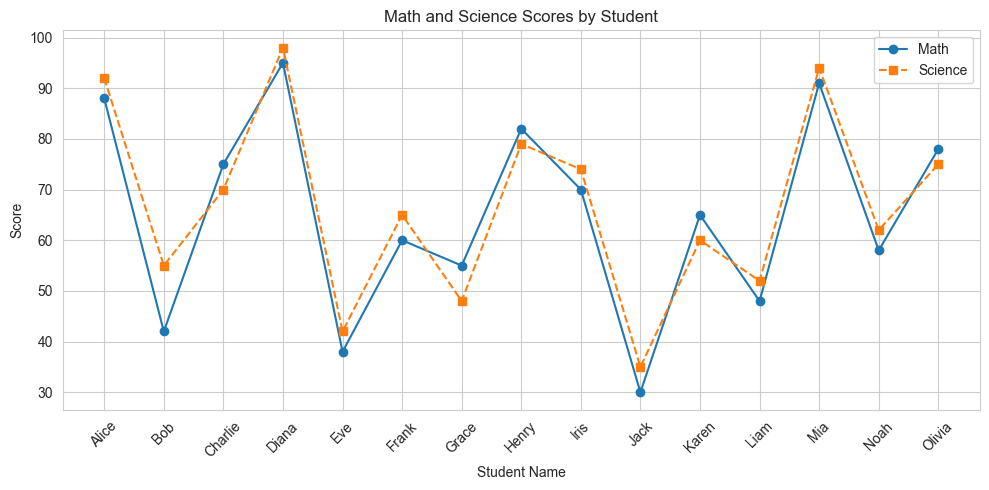

In [16]:
# Plot 5: line plot for math and science scores for every student

plt.figure(figsize=(10, 5))

plt.plot(df["name"], df["math"], marker="o", linestyle="-", label="Math")
plt.plot(df["name"], df["science"], marker="s", linestyle="--", label="Science")

plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("plot5_line.png")
plt.show()

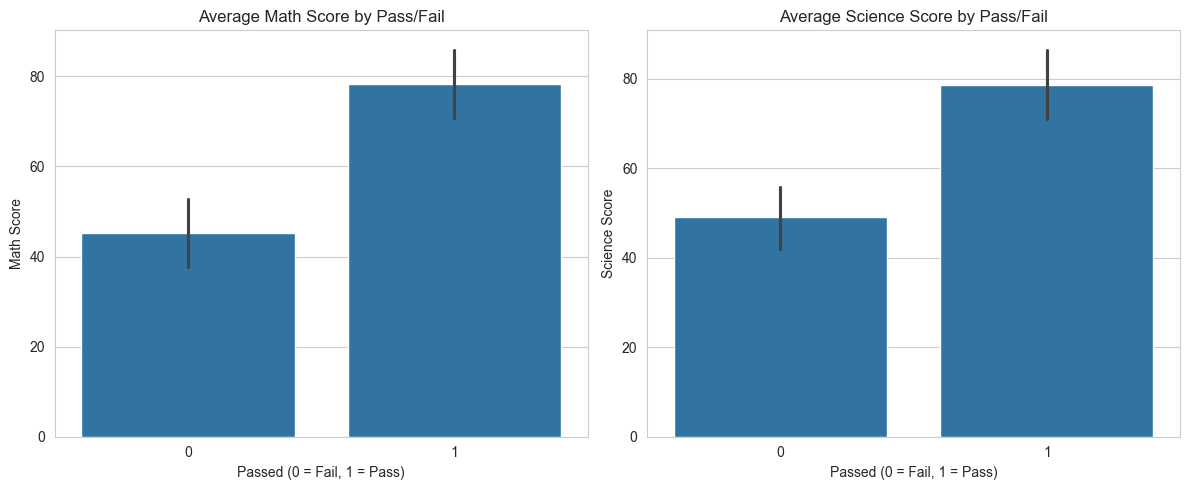

In [17]:
# Plot 6: seaborn bar plots for average math and science scores split by pass/fail

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x="passed", y="math", ax=axes[0])
axes[0].set_title("Average Math Score by Pass/Fail")
axes[0].set_xlabel("Passed (0 = Fail, 1 = Pass)")
axes[0].set_ylabel("Math Score")

sns.barplot(data=df, x="passed", y="science", ax=axes[1])
axes[1].set_title("Average Science Score by Pass/Fail")
axes[1].set_xlabel("Passed (0 = Fail, 1 = Pass)")
axes[1].set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

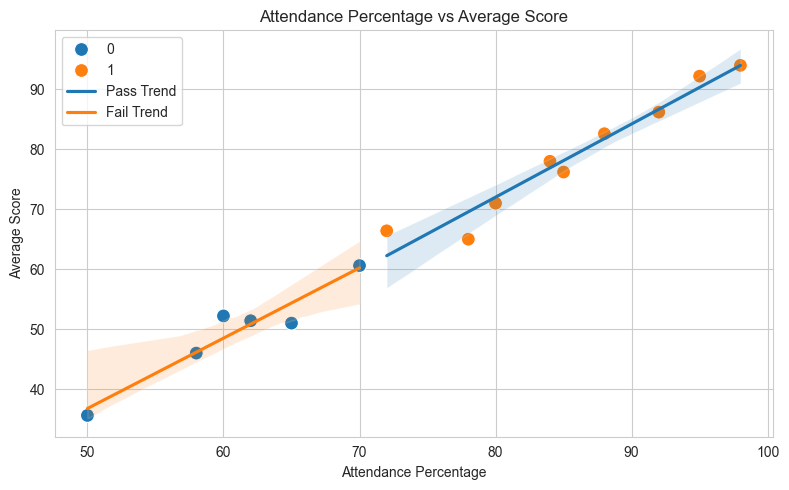

In [18]:
# Plot 7: seaborn scatter plot of attendance vs avg_score
# also adding regression line separately for pass and fail students

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="attendance_pct", y="avg_score", hue="passed", s=100)

sns.regplot(
    data=df[df["passed"] == 1],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Pass Trend"
)

sns.regplot(
    data=df[df["passed"] == 0],
    x="attendance_pct",
    y="avg_score",
    scatter=False,
    label="Fail Trend"
)

plt.title("Attendance Percentage vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [19]:
# In my experience, Matplotlib gave me more control over each plot,
# but it required more manual work for formatting and layout.
# Seaborn felt easier and cleaner for statistical-style plots,
# especially when comparing categories like pass and fail groups.

In [20]:
# preparing features (X) and target (y)
# keeping the original df unchanged, so I am only selecting needed columns for X

feature_cols = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]

X = df[feature_cols]
y = df["passed"]

print("Features and target prepared.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target prepared.
X shape: (15, 7)
y shape: (15,)


In [21]:
# splitting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# TRAIN-TEST SPLIT
# splitting dataset into training and testing parts
# random_state ensures same split every time for consistency
print("Train-test split completed.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train-test split completed.
Training samples: 12
Testing samples: 3


In [22]:
# scaling the features using StandardScaler
# fit only on training data, then transform both train and test

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [23]:
# training logistic regression model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)

print("Model trained successfully.")
print(f"Training Accuracy: {train_accuracy:.2f}")

Model trained successfully.
Training Accuracy: 1.00


In [24]:
# making predictions on the test set

y_pred = model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.2f}")

Test Accuracy: 1.00


In [25]:
# printing student name, actual result, predicted result, and whether prediction was correct

test_names = df.loc[X_test.index, "name"]

print("Prediction results for test students:\n")

for idx, student_name in zip(X_test.index, test_names):
    actual = df.loc[idx, "passed"]

    # finding the predicted value using position inside X_test
    pred_position = list(X_test.index).index(idx)
    predicted = y_pred[pred_position]

    if actual == predicted:
        result_symbol = "✅ correct"
    else:
        result_symbol = "❌ wrong"

    print(f"{student_name} -> Actual: {actual}, Predicted: {predicted}, {result_symbol}")

Prediction results for test students:

Jack -> Actual: 0, Predicted: 0, ✅ correct
Liam -> Actual: 0, Predicted: 0, ✅ correct
Alice -> Actual: 1, Predicted: 1, ✅ correct


In [26]:
# logistic regression coefficients show how strongly each feature affects prediction
# positive means more likely to predict pass
# negative means more likely to predict fail

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": coefficients
})

coef_df["Absolute_Value"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(by="Absolute_Value", ascending=False)

print("Feature coefficients sorted by absolute value:")
coef_df

Feature coefficients sorted by absolute value:


,Feature,Coefficient,Absolute_Value
2,english,0.812513,0.812513
5,attendance_pct,0.521876,0.521876
6,study_hours_per_day,0.484433,0.484433
4,pe,0.474974,0.474974
0,math,0.437944,0.437944
1,science,0.323010,0.323010
3,history,0.262929,0.262929


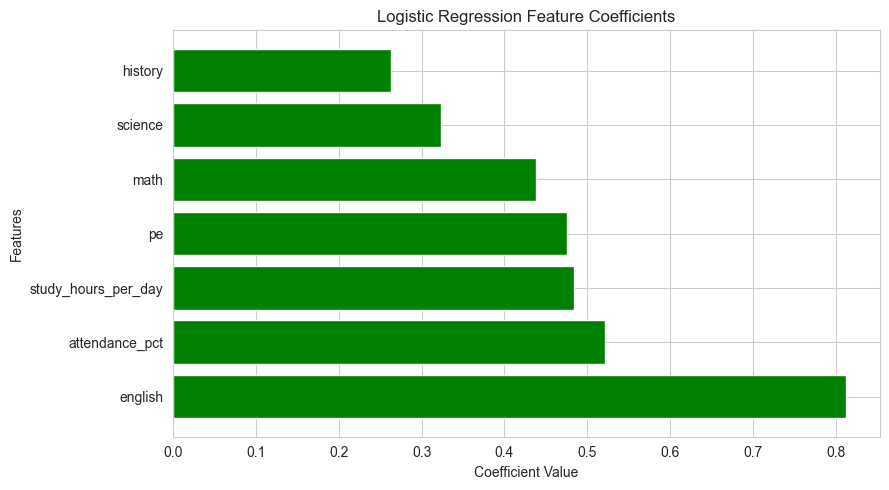

In [27]:
# horizontal bar chart of feature coefficients
# green for positive, red for negative

colors = ["green" if value > 0 else "red" for value in coef_df["Coefficient"]]

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()

plt.show()

In [28]:
# predicting pass/fail for a new student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

new_student_scaled = scaler.transform(new_student)

new_prediction = model.predict(new_student_scaled)[0]
new_probability = model.predict_proba(new_student_scaled)[0]

if new_prediction == 1:
    prediction_label = "Pass"
else:
    prediction_label = "Fail"

print("Prediction for new student:")
print("Predicted Result:", prediction_label)
print(f"Probability of Fail (0): {new_probability[0]:.4f}")
print(f"Probability of Pass (1): {new_probability[1]:.4f}")

Prediction for new student:
Predicted Result: Pass
Probability of Fail (0): 0.0920
Probability of Pass (1): 0.9080


c:\Users\Kahani Tharayil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
